# Data Reset

Author: Pete King

This notebook implements a fresh download of asset price data for selected ETFs, market sentiment indicator data, and other useful indicies from Yahoo Finance.  This serves to correct data reliability issues with NaN values introduced after merging ETF data with market index data.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import json
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import data_prep as dp

## I. Sector ETF price data

In [2]:
# Copied from Tom's Yahoo Finance notebook
sector_etfs = [
    # Broad equity
    "SPY", "QQQ", "IWM",
    # GICS sectors
    "XLF", "XLK", "XLU", "XLV", "XLE", "XLI", "XLB", "XLP", "XLY",
    # Fixed income — short / intermediate / long / credit / inflation
    "BIL", "BND", "IEF", "TLT", "LQD", "HYG", "TIP",
    # Real assets
    "XLRE", "GLD"
]
# price data
etf_df = yf.download(sector_etfs, period='max', auto_adjust=True)['Close']

[*********************100%***********************]  21 of 21 completed


In [3]:
etf_df

Ticker,BIL,BND,GLD,HYG,IEF,IWM,LQD,QQQ,SPY,TIP,...,XLB,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,,,,,,,,,,
1993-01-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.175381,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.347315,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.398914,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.656811,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.760000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-25,91.580002,73.540001,416.290009,79.419998,95.360001,251.820007,108.730003,587.820007,656.820007,110.160004,...,49.410000,60.570000,49.340000,165.100006,136.759995,81.510002,40.270000,45.250000,146.240005,110.730003
2026-03-26,91.599998,73.110001,400.640015,78.919998,94.589996,247.440002,107.879997,573.789978,645.090027,109.760002,...,49.090000,61.520000,49.049999,161.270004,132.500000,81.139999,40.290001,45.330002,145.740005,108.830002
2026-03-27,91.629997,73.110001,414.700012,78.720001,94.599998,243.100006,107.620003,562.580017,634.090027,109.669998,...,48.910000,62.560001,47.810001,159.199997,129.919998,81.779999,40.009998,45.590000,143.259995,105.680000


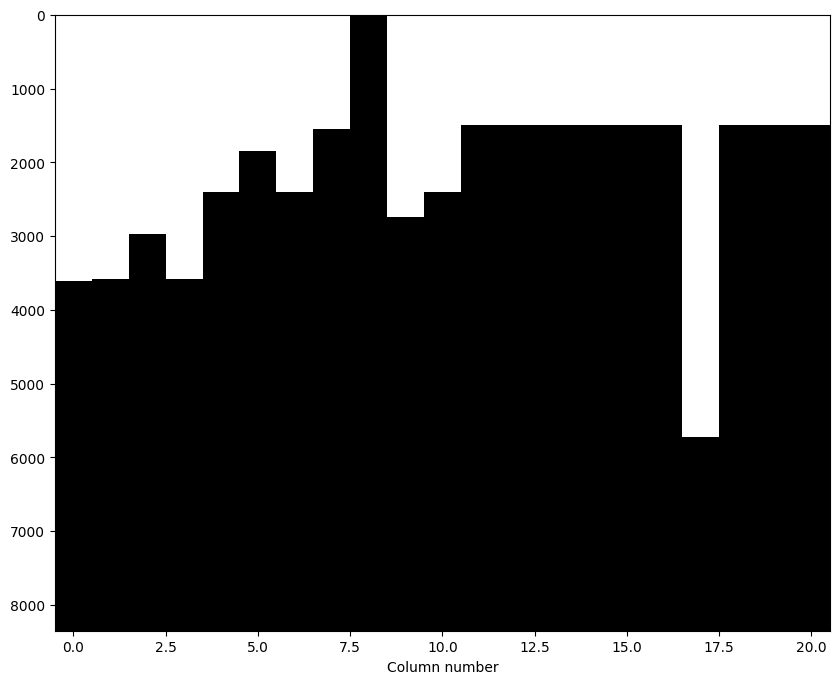

In [4]:
dp.view_nan(etf_df);

Looks good, no interspersed NaN values... let's save the raw data to disk.

In [5]:
etf_df.to_csv('etf_raw_data.csv', index_label='date')

## II. Market sentiment and other indicies

In [6]:
# Copied from Tom's Yahoo Finance notebook, modified to remove redundant columns:
# TLT, LQD, HYG
indicies = [
    "^VIX",
    "^VXN",
    "^MOVE",
    "DX-Y.NYB",
    "^TNX",
    "GC=F",
    "CL=F",
    "NG=F",
    "HG=F",
    "SHY",
    "^FTSE",
    "^HSI",
    "^GSPC"
]
indicies_df = yf.download(indicies, period='max', auto_adjust=True)['Close']
# We may need to run the data with more historical data but less features and more features but less historical data to see what works best for our model but keep in mind the impact that it will have on out of sample data.

[*********************100%***********************]  13 of 13 completed


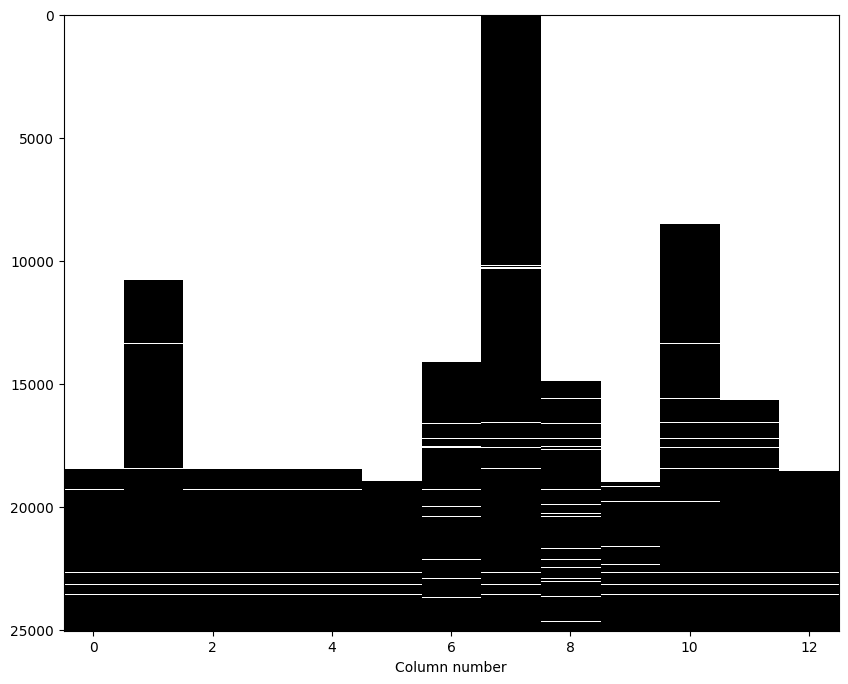

In [7]:
dp.view_nan(indicies_df);

In [8]:
# This data has a lot of missing values, but lets save the raw data pull 
# in case we need to refer back to 'ground truth' in the future.
indicies_df.to_csv('indicies_raw_data.csv', index_label='date')

### Finding a common starting date

In [9]:
# Find the earliest start date common to all indicies.
start_date = indicies_df.dropna().index[0]
start_date

Timestamp('2002-11-12 00:00:00')

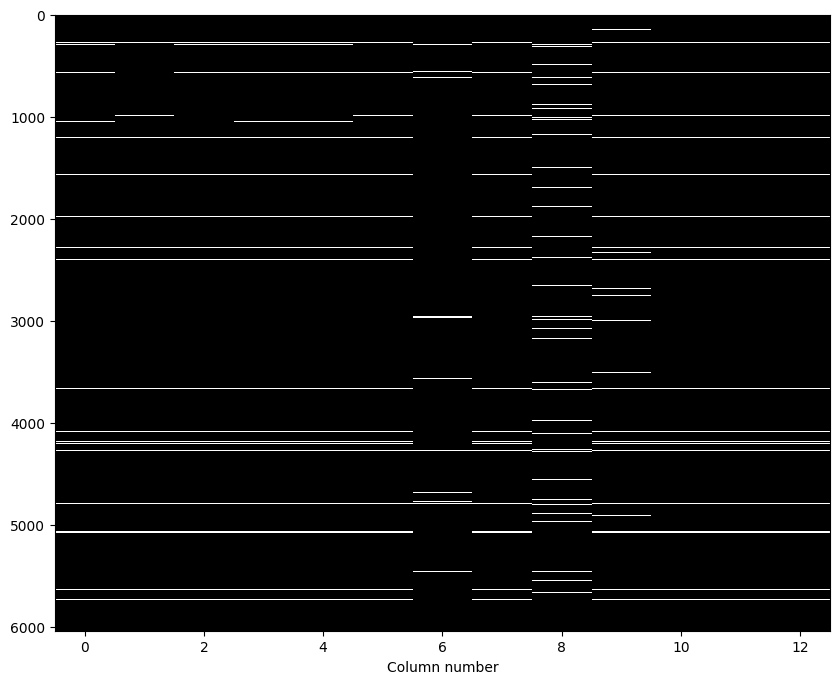

In [10]:
dp.view_nan(indicies_df[start_date:]);

In [11]:
percent_missing = (
    1 - len(indicies_df[start_date:].dropna()) / len(indicies_df[start_date:])
)
print(f'Largest percent of missing data among all indicies: \
{percent_missing * 100:2.1f} percent')

Largest percent of missing data among all indicies: 9.7 percent


### Data Imputation Discussion

This chunk of data is common to all indices from 2002.  The index with the most missing values (visually) is HIX, but most have a smaller fraction of data missing.  We can safely impute the missing values without serious distortion of the data.  We would like to interpolate data, but since we are using time series, this risks introducing data leakage as filled values will trend towards future values.

Imputation is still desired over a forward-fill method, however, since we intend to compute daily returns and volatility as features.  These features are based on a difference between successive observations.  A forward-fill would create situations where there are interspersed zero values, whereas imputation would spread the difference out over time.  Niether situation is ideal, but a series of reduced returns should represent real-world behavior better than a single realistic return value followed by a series of zero-valued returns.

To further guard against data leakage between training and validation/test sets, we will later introduce a buffer of 63 business days (one quarter) between splits.

In [12]:
filled_indicies_df = indicies_df[start_date:].interpolate(method='linear')
filled_indicies_df

Ticker,CL=F,DX-Y.NYB,GC=F,HG=F,NG=F,SHY,^FTSE,^GSPC,^HSI,^MOVE,^TNX,^VIX,^VXN
Date,,,,,,,,,,,,,
2002-11-12,25.900000,104.660004,324.500000,0.7190,3.872,52.662022,4085.100098,882.950012,9613.839844,120.209999,3.851,30.580000,55.250000
2002-11-13,25.190001,105.099998,318.700012,0.7155,3.877,52.668507,4029.399902,882.530029,9616.620117,122.879997,3.838,31.240000,54.459999
2002-11-14,25.290001,105.209999,317.899994,0.7105,3.869,52.540073,4053.100098,904.270020,9740.839844,130.289993,4.021,28.670000,52.400002
2002-11-15,25.510000,105.040001,320.700012,0.7170,3.981,52.565666,4091.600098,909.830017,9865.650391,132.350006,4.051,26.650000,49.680000
2002-11-18,26.709999,105.199997,319.200012,0.7270,4.263,52.565666,4116.000000,900.359985,9920.089844,129.139999,4.019,27.660000,48.090000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-25,90.320000,99.599998,4549.799805,5.5290,2.952,82.400002,10106.799805,6591.899902,25335.949219,97.589996,4.328,25.330000,27.650000
2026-03-26,94.480003,99.900002,4375.500000,5.4465,2.999,82.220001,9972.200195,6477.160156,24856.429688,115.019997,4.416,27.440001,29.860001
2026-03-27,99.639999,100.150002,4492.000000,5.4670,3.095,82.389999,9967.400391,6368.850098,24951.880859,111.949997,4.440,31.049999,33.540001


*Note: During a subsequent Feature Engineering step, we found an instance where the value of one of the price indicies is less than zero -- something that would not occur in the real world.  We display and correct this data deficiency below.*

In [13]:
indicies_df['CL=F'][indicies_df['CL=F'] < 0]

Date
2020-04-20   -37.630001
Name: CL=F, dtype: float64

In [14]:
filled_indicies_df['CL=F']['2020-04-15':'2020-04-25']

Date
2020-04-15    19.870001
2020-04-16    19.870001
2020-04-17    18.270000
2020-04-20   -37.630001
2020-04-21    10.010000
2020-04-22    13.780000
2020-04-23    16.500000
2020-04-24    16.940001
Name: CL=F, dtype: float64

In [15]:
if filled_indicies_df.loc['2020-04-20', 'CL=F'] < 0:
    filled_indicies_df.loc['2020-04-20', 'CL=F'] = (
        float(filled_indicies_df.loc['2020-04-17', 'CL=F'])
        + float(filled_indicies_df.loc['2020-04-21', 'CL=F'])
    ) / 2
filled_indicies_df['CL=F']['2020-04-15':'2020-04-25']

Date
2020-04-15    19.870001
2020-04-16    19.870001
2020-04-17    18.270000
2020-04-20    14.140000
2020-04-21    10.010000
2020-04-22    13.780000
2020-04-23    16.500000
2020-04-24    16.940001
Name: CL=F, dtype: float64

In [16]:
# Save the imputed market indicies data for further analysis
filled_indicies_df.to_csv('filled_indicies_data.csv', index_label='date')